# Exploratory Data Analysis in Python
## Customer value: a continuous response variable

**Regression Analysis · Data Science Engineering · ITESO**

---

Modelling cycle has five steps and that step 1 is *data collection and exploratory analysis*.  This notebook is that step, done properly, in Python.

We will **not** fit any model. The goal is to arrive at step 2 — formulation — knowing what the response looks like, which variables matter and in what shape, and what is broken in the data.

### Business case

An online fashion retailer operating in Mexico, two years of history. Marketing needs to decide **how much it can afford to pay to acquire a customer in each channel**.

The logic is simple: if acquiring a customer through Instagram costs \$389 and that customer spends \$494 in their first year, the channel barely breaks even. If the cost is \$123 and they spend \$739, it is excellent.

Our response variable is `gasto_12m` — **total spend in the customer's first 12 months**. It is a practical proxy for lifetime value: continuous, strictly positive, and with no censoring, because the window is fixed.

### Temporal structure

The columns do not all live in the same moment in time. They fall into three groups:

| Group | When it is known | Columns |
|---|---|---|
| **Day 0** | At acquisition | `canal_adquisicion`, `cac_mxn`, `cohorte_mes`, `ciudad`, `dedispositivo_registro`, `edad`, `newsletter`, `descuento_primera` |
| **90 days** | After one quarter | `pedidos_90d`, `dias_a_segunda_compra_90d`, `tasa_devolucion_90d`, `activo_app_90d` |
| **12 months** | The response | `gasto_12m` |

Keeping this straight is not bureaucracy. It decides **which variables you are allowed to use** for a given business question, and we come back to it at the end.

### Variables

| Column | Meaning | Type | Window |
|---|---|---|---|
| `id_cliente` | Customer identifier | ID | — |
| `canal_adquisicion` | Acquisition channel | Nominal | Day 0 |
| `cac_mxn` | Customer acquisition cost, MXN | Continuous | Day 0 |
| `cohorte_mes` | Month of signup, 1–12 | Ordinal, cyclical | Day 0 |
| `ciudad` | City of residence | Nominal | Day 0 |
| `dispositivo_registro` | Device used at signup | Nominal | Day 0 |
| `edad` | Age, years | Continuous | Day 0 |
| `newsletter` | Opted into the newsletter | Binary | Day 0 |
| `descuento_primera` | Discount on the first order, % | Continuous | Day 0 |
| `monto_primera_compra` | First order value, MXN | Continuous | Day 0 |
| `categoria_primera` | Category of the first order | Nominal | Day 0 |
| `piezas_primera` | Items in the first order | Count | Day 0 |
| `pedidos_90d` | Orders placed after the first, within 90 days | Count | 90 days |
| `dias_a_segunda_compra_90d` | Days elapsed until the second order | Continuous | 90 days |
| `tasa_devolucion_90d` | Share of purchased items returned | Continuous, 0–1 | 90 days |
| `activo_app_90d` | Activated the mobile app | Binary | 90 days |
| **`gasto_12m`** | **Total spend in the first 12 months — the response** | **Continuous** | **12 months** |


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

TEAL, CORAL, GREY = "#0F7173", "#D9622B", "#5C6B70"

---
# 1. First contact

How big is it, what columns are there, and what type is each one?

In [3]:
df = pd.read_csv("Data_LTV_EDA_vf.csv")

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 2,015   Columns: 17


,id_cliente,canal_adquisicion,cac_mxn,cohorte_mes,ciudad,dispositivo_registro,edad,newsletter,descuento_primera,monto_primera_compra,categoria_primera,piezas_primera,pedidos_90d,dias_a_segunda_compra_90d,tasa_devolucion_90d,activo_app_90d,gasto_12m
0,501500,Organico,93.0,4,CDMX,Tablet,30.0,1,0,1100.0,Deportivo,2,2,19.0,0.220,0,1215.0
1,500974,Google Ads,364.0,10,CDMX,Movil,27.0,0,5,599.0,Accesorios,2,1,15.0,0.594,0,743.0
2,500776,Referido,185.0,2,CDMX,Movil,37.0,1,0,462.0,Calzado,3,9,2.0,0.604,1,1343.0
3,501406,Afiliados,209.0,6,Monterrey,Escritorio,35.0,0,0,337.0,Ropa,3,0,NaN,0.000,0,337.0
4,501904,Google Ads,323.0,8,Puebla,Escritorio,39.0,0,15,179.0,Ropa,1,1,14.0,0.011,0,515.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 2015 non-null   int64  
 1   canal_adquisicion          2015 non-null   str    
 2   cac_mxn                    1914 non-null   float64
 3   cohorte_mes                2015 non-null   int64  
 4   ciudad                     2015 non-null   str    
 5   dispositivo_registro       2015 non-null   str    
 6   edad                       1835 non-null   float64
 7   newsletter                 2015 non-null   int64  
 8   descuento_primera          2015 non-null   int64  
 9   monto_primera_compra       2015 non-null   float64
 10  categoria_primera          2015 non-null   str    
 11  piezas_primera             2015 non-null   int64  
 12  pedidos_90d                2015 non-null   int64  
 13  dias_a_segunda_compra_90d  1463 non-null   float64
 14  tas

- `cac_mxn`, `edad`, `dias_a_segunda_compra_90d` and `gasto_12m` have **fewer non-null values** than the row count. There are missing data, and one of those columns has a lot of them.
- `dias_a_segunda_compra_90d` is missing in over a quarter of the rows. Hold that thought.
- Everything typed as `object` is a text column that will need checking.

---
# 2. Data quality

## 2.1 Duplicate rows

In [5]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Repeated customer IDs:", df["id_cliente"].duplicated().sum())

df[df.duplicated(keep=False)].sort_values("id_cliente")

Fully duplicated rows: 15
Repeated customer IDs: 15


,id_cliente,canal_adquisicion,cac_mxn,cohorte_mes,ciudad,dispositivo_registro,edad,newsletter,descuento_primera,monto_primera_compra,categoria_primera,piezas_primera,pedidos_90d,dias_a_segunda_compra_90d,tasa_devolucion_90d,activo_app_90d,gasto_12m
593,500078,Instagram,564.0,6,Monterrey,Movil,32.0,0,5,605.0,Calzado,1,0,NaN,0.000,1,693.0
1737,500078,Instagram,564.0,6,Monterrey,Movil,32.0,0,5,605.0,Calzado,1,0,NaN,0.000,1,693.0
775,500131,Organico,110.0,5,Guadalajara,Escritorio,40.0,0,5,442.0,Calzado,1,1,21.0,0.360,1,805.0
1147,500131,Organico,110.0,5,Guadalajara,Escritorio,40.0,0,5,442.0,Calzado,1,1,21.0,0.360,1,805.0
1562,500208,Organico,103.0,5,CDMX,Movil,31.0,0,0,464.0,Calzado,1,4,36.0,0.555,0,1055.0
544,500208,Organico,103.0,5,CDMX,Movil,31.0,0,0,464.0,Calzado,1,4,36.0,0.555,0,1055.0
1494,500290,Referido,154.0,12,CDMX,Escritorio,28.0,1,5,571.0,Calzado,4,2,9.0,0.221,1,895.0
1219,500290,Referido,154.0,12,CDMX,Escritorio,28.0,1,5,571.0,Calzado,4,2,9.0,0.221,1,895.0
466,500446,Referido,110.0,3,CDMX,Movil,36.0,0,10,-592.0,Deportivo,1,3,4.0,0.170,1,NaN
276,500446,Referido,110.0,3,CDMX,Movil,36.0,0,10,-592.0,Deportivo,1,3,4.0,0.170,1,NaN


In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows after dropping duplicates: {df.shape[0]:,}")

Rows after dropping duplicates: 2,000


## 2.2 Impossible values

Missing data announces itself. **Impossible values do not** — they sit quietly looking like real
numbers. The only way to find them is to ask what each variable is physically allowed to be.

In [7]:
checks = {
    "monto_primera_compra <= 0": (df["monto_primera_compra"] <= 0).sum(),
    "gasto_12m <= 0":            (df["gasto_12m"] <= 0).sum(),
    "edad < 15":                 (df["edad"] < 15).sum(),
    "edad > 95":                 (df["edad"] > 95).sum(),
    "cac_mxn < 0":               (df["cac_mxn"] < 0).sum(),
    "tasa_devolucion_90d > 1":   (df["tasa_devolucion_90d"] > 1).sum(),
    "gasto_12m < monto_primera": (df["gasto_12m"] < df["monto_primera_compra"]).sum(),
}

pd.Series(checks, name="count").to_frame()

,count
monto_primera_compra <= 0,5
gasto_12m <= 0,4
edad < 15,4
edad > 95,0
cac_mxn < 0,0
tasa_devolucion_90d > 1,0
gasto_12m < monto_primera,4


The last check is a **logical consistency** rule rather than a range rule: total spend in 12 months
cannot be less than the first order, because the first order is part of it. Rules like this one come
from understanding the business, not from looking at the numbers.

We convert the impossible values to `NaN` rather than deleting the rows — the rest of each row may
be perfectly valid.

In [8]:
df.loc[df["monto_primera_compra"] <= 0, "monto_primera_compra"] = np.nan
df.loc[df["gasto_12m"] <= 0, "gasto_12m"] = np.nan
df.loc[df["edad"] < 15, "edad"] = np.nan

print("New missing counts:")
df[["monto_primera_compra", "gasto_12m", "edad"]].isna().sum()

New missing counts:


monto_primera_compra      5
gasto_12m                64
edad                    183
dtype: int64

## 2.3 Inconsistent categories

Text columns captured by humans or merged from several systems are almost always dirty.

In [9]:
for col in ["canal_adquisicion", "ciudad", "categoria_primera", "dispositivo_registro"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- canal_adquisicion ---
canal_adquisicion
Instagram     542
Google Ads    447
Organico      372
Afiliados     349
Referido      252
instagram      20
 Referido      18
Name: count, dtype: int64

--- ciudad ---
ciudad
CDMX           737
Guadalajara    383
Monterrey      315
Puebla         313
Merida         230
Sin dato        22
Name: count, dtype: int64

--- categoria_primera ---
categoria_primera
Ropa          862
Calzado       536
Accesorios    385
Deportivo     217
Name: count, dtype: int64

--- dispositivo_registro ---
dispositivo_registro
Movil         1296
Escritorio     571
Tablet         133
Name: count, dtype: int64



Three problems:

- `"instagram"` in lowercase is a *different string* from `"Instagram"`
- `" Referido"` with a leading space is a different string from `"Referido"`
- `"Sin dato"` in `ciudad` is a missing value wearing a costume

If you group by channel without fixing this, Instagram gets split across two rows and both look
smaller than they are.

In [10]:
df["canal_adquisicion"] = df["canal_adquisicion"].str.strip().str.title()
df["ciudad"] = df["ciudad"].replace({"Sin dato": np.nan})

print(df["canal_adquisicion"].value_counts(dropna=False))
print("Missing cities:", df["ciudad"].isna().sum())

canal_adquisicion
Instagram     562
Google Ads    447
Organico      372
Afiliados     349
Referido      270
Name: count, dtype: int64
Missing cities: 22


## 2.4 Missing values: how much and where

In [11]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "%": (df.isna().mean() * 100).round(1),
}).sort_values("n_missing", ascending=False)

missing[missing["n_missing"] > 0]

,n_missing,%
dias_a_segunda_compra_90d,546,27.3
edad,183,9.2
cac_mxn,100,5.0
gasto_12m,64,3.2
ciudad,22,1.1
monto_primera_compra,5,0.2


`dias_a_segunda_compra_90d` is missing in more than a quarter of rows.

---
# 3. The three kinds of missingness

This is what decides what you are allowed to do.

| Type | Meaning | What you can do |
|---|---|---|
| **MCAR** | Missing Completely At Random | Dropping rows is unbiased |
| **MAR** | Depends on *observed* variables | Impute using those variables |
| **MNAR** | Depends on the *unobserved value itself* | Nothing statistical saves you |

There is a fourth case that does not appear in most textbooks and is the most important one here.

## 3.1 Structural missingness — the `NaN` that is not missing at all

In [12]:
df.groupby(df["dias_a_segunda_compra_90d"].isna()).agg(
    n=("id_cliente", "size"),
    pedidos_90d_mean=("pedidos_90d", "mean"),
    gasto_12m_mean=("gasto_12m", "mean"),
)

,n,pedidos_90d_mean,gasto_12m_mean
dias_a_segunda_compra_90d,,,
False,1454,2.0337,895.004972
True,546,0.0000,651.219697


### The finding

Every customer with a missing value has **zero orders in the first 90 days**. That is not a data
collection failure — **there is no second purchase date because there was no second purchase.**

The `NaN` is not a lost value. It is the answer: *this customer did not come back within the window*.

### Why this matters

Look at the mean spend: customers who came back spend roughly **twice as much**. If you imputed this
column with the median, you would be telling the model that every one-time buyer came back on a
typical day. You would erase the most predictive distinction in the entire dataset.

### The correct treatment

1. Create an **indicator** that captures the fact
2. Fill the numeric column with a value that is only used *when the indicator says so*
3. Never let the imputed number be read as a real observation

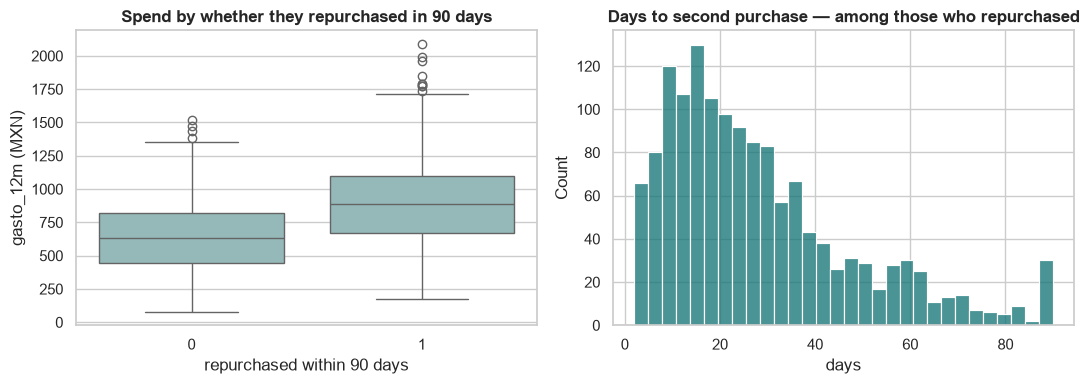

In [13]:
df["recompro_90d"] = df["dias_a_segunda_compra_90d"].notna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x="recompro_90d", y="gasto_12m", ax=axes[0], color="#8FBFBF")
axes[0].set_title("Spend by whether they repurchased in 90 days")
axes[0].set_xlabel("repurchased within 90 days")
axes[0].set_ylabel("gasto_12m (MXN)")

sub = df[df["recompro_90d"] == 1]
sns.histplot(sub["dias_a_segunda_compra_90d"], bins=30, color=TEAL, ax=axes[1])
axes[1].set_title("Days to second purchase — among those who repurchased")
axes[1].set_xlabel("days")

plt.tight_layout()
plt.show()

> **The rule to remember.** Before imputing any column, ask: *is this value missing, or does it not
> exist?* If it does not exist, imputation is not a technical choice — it is an error.

## 3.2 MAR — missingness that depends on an observed variable

In [14]:
tab = pd.crosstab(df["canal_adquisicion"], df["edad"].isna(), normalize="index") * 100
tab.columns = ["Present (%)", "Missing (%)"]
tab = tab.sort_values("Missing (%)", ascending=False).round(1)
tab

,Present (%),Missing (%)
canal_adquisicion,,
Afiliados,66.2,33.8
Organico,94.6,5.4
Referido,95.9,4.1
Instagram,96.3,3.7
Google Ads,97.1,2.9


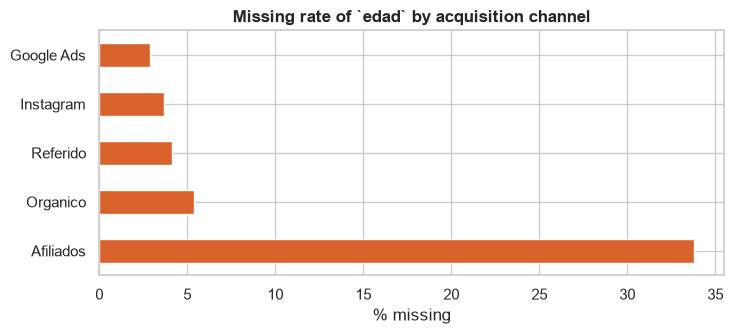

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 3.5))
tab["Missing (%)"].plot(kind="barh", color=CORAL, ax=ax)
ax.set_title("Missing rate of `edad` by acquisition channel")
ax.set_xlabel("% missing")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### The finding

Age is missing far more often for customers acquired through **Afiliados**. The explanation is
operational: that channel uses an express signup form that does not ask for a date of birth.

This is **MAR** — missingness that depends on a variable we can see. Two consequences:

1. Dropping those rows would systematically under-represent the Afiliados channel, which happens to
   be the channel with the lowest customer value. The analysis would look better than reality.
2. Imputing with the **global** mean would pull those customers towards the overall average and
   erase whatever is distinctive about the channel.

The correct imputation uses the channel.

---
# 4. Imputation

| Strategy | When it is reasonable | What it costs |
|---|---|---|
| Drop rows | MCAR and very few rows | Loses information; biased under MAR |
| Mean | Symmetric variable | Shrinks the variance |
| Median | Skewed variable | Shrinks the variance |
| Group median | MAR — you know what it depends on | Preserves group structure |
| Indicator + fill | Structural missingness | Adds a column |

/
> **The rule that is easy to forget:** never impute the **response**. If `gasto_12m` is missing you
> do not know the answer, and inventing it means learning from values you made up.

In [16]:
n_before = len(df)
df = df.dropna(subset=["gasto_12m"]).reset_index(drop=True)
print(f"Rows dropped because the response was missing: {n_before - len(df)}")
print(f"Rows remaining: {len(df):,}")

Rows dropped because the response was missing: 64
Rows remaining: 1,936


In [17]:
# `edad` — MAR, so we impute within the channel and keep an indicator
print("Median age by channel:")
print(df.groupby("canal_adquisicion")["edad"].median())

df["edad"] = df.groupby("canal_adquisicion")["edad"].transform(lambda s: s.fillna(s.median()))
print("\nMissing values remaining:", df["edad"].isna().sum())

Median age by channel:
canal_adquisicion
Afiliados     35.0
Google Ads    34.0
Instagram     34.0
Organico      35.0
Referido      33.0
Name: edad, dtype: float64

Missing values remaining: 0


In [18]:
# `cac_mxn` — cost is a property of the channel and the cohort
df["cac_mxn"] = df.groupby(["canal_adquisicion", "cohorte_mes"])["cac_mxn"].transform(
    lambda s: s.fillna(s.median())
)

df["cac_mxn"] = df["cac_mxn"].fillna(df["cac_mxn"].median())   # any group left empty

In [19]:
# `monto_primera_compra` — skewed, so median
df["monto_primera_compra"] = df["monto_primera_compra"].fillna(df["monto_primera_compra"].median())

# `ciudad` — categorical, mode
df["ciudad"] = df["ciudad"].fillna(df["ciudad"].mode().iloc[0])

In [20]:
# `dias_a_segunda_compra_90d` — STRUCTURAL. Fill with a sentinel, never with a central value.
# The indicator `recompro_90d` is what carries the information.
df["dias_a_segunda_compra_90d"] = df["dias_a_segunda_compra_90d"].fillna(-1)

print("Total missing values remaining:", df.isna().sum().sum())

Total missing values remaining: 0


The `-1` sentinel is deliberately impossible: no one can repurchase in negative days. Anyone reading
this column later is forced to notice that the value is not a real measurement, and any summary
statistic on it will look obviously wrong. That is a feature, not a bug.

## What imputation costs you

Filling with a central value **shrinks the variance**, because you are adding observations that sit
exactly at the centre. Always measure how much you moved things.

In [21]:
raw = pd.read_csv("Data_LTV_EDA_vf.csv")

comp = pd.DataFrame({
    "before": [raw["edad"].mean(), raw["edad"].std()],
    "after":  [df["edad"].mean(),  df["edad"].std()],
}, index=["mean", "std"])
comp["change_%"] = ((comp["after"] / comp["before"] - 1) * 100).round(2)
comp

,before,after,change_%
mean,34.238147,34.345041,0.31
std,9.187343,8.697486,-5.33


The mean barely moves — that is what a good imputation looks like. The standard deviation falls, and
that fall is the price: your uncertainty estimates will end up slightly too optimistic.

With 9% of a column imputed this is acceptable. With 40% it is not, and the honest report says the
variable is unusable rather than quietly filling it in.

---
# 5. The response variable

The question from topic 1.1: **what is the shape of the distribution?** That is what decides which
distribution is admissible in step 2.

In [22]:
df["gasto_12m"].describe()

count    1936.000000
mean      828.518079
std       318.232136
min        78.000000
25%       603.000000
50%       807.000000
75%      1042.000000
max      2090.000000
Name: gasto_12m, dtype: float64

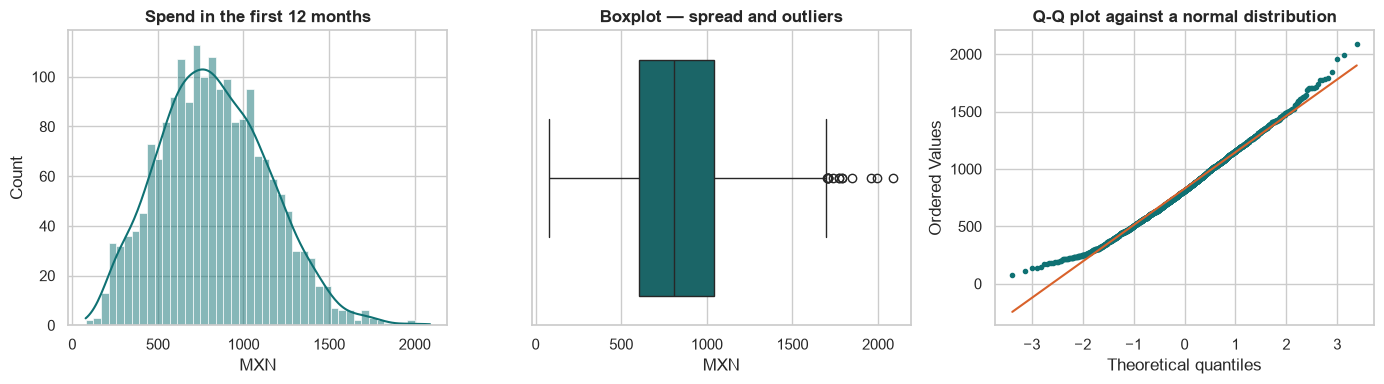

In [23]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df["gasto_12m"], bins=45, kde=True, color=TEAL, ax=axes[0])
axes[0].set_title("Spend in the first 12 months")
axes[0].set_xlabel("MXN")

sns.boxplot(x=df["gasto_12m"], color=TEAL, ax=axes[1])
axes[1].set_title("Boxplot — spread and outliers")
axes[1].set_xlabel("MXN")

stats.probplot(df["gasto_12m"], dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot against a normal distribution")
axes[2].get_lines()[0].set_color(TEAL)
axes[2].get_lines()[0].set_markersize(3)
axes[2].get_lines()[1].set_color(CORAL)

plt.tight_layout()
plt.show()

In [24]:
print(f"Mean:     $ {df['gasto_12m'].mean():,.0f}")
print(f"Median:   $ {df['gasto_12m'].median():,.0f}")
print(f"Skewness:   {df['gasto_12m'].skew():.2f}   (0 = symmetric)")
print(f"Minimum:  $ {df['gasto_12m'].min():,.0f}")
print(f"P95:      $ {df['gasto_12m'].quantile(0.95):,.0f}")
print(f"Maximum:  $ {df['gasto_12m'].max():,.0f}")

Mean:     $ 829
Median:   $ 807
Skewness:   0.31   (0 = symmetric)
Minimum:  $ 78
P95:      $ 1,370
Maximum:  $ 2,090


### Reading it

1. **Strictly positive.** Every customer made at least one purchase, so the floor is above zero.
2. **Close to symmetric.** The mean and the median almost coincide and the skewness is small. The
   histogram has the familiar bell shape, with a mild right tail.
3. **The Q-Q plot follows the reference line** through the bulk of the distribution, drifting only at
   the extremes — which is where there are fewest observations and where drift is expected.

Together: symmetric enough, and with no departure large enough to rule out a normal model.

### Where the value is concentrated

---
# 6. The business question: LTV against CAC

Before looking at individual relationships, answer the question marketing actually asked.

In [25]:
channel = df.groupby("canal_adquisicion").agg(
    n=("id_cliente", "size"),
    ltv_promedio=("gasto_12m", "mean"),
    ltv_mediana=("gasto_12m", "median"),
    cac_promedio=("cac_mxn", "mean"),
).round(0)

channel["ratio_ltv_cac"] = (channel["ltv_promedio"] / channel["cac_promedio"]).round(2)
channel["margen"] = (channel["ltv_promedio"] - channel["cac_promedio"]).round(0)
channel.sort_values("ratio_ltv_cac", ascending=False)

,n,ltv_promedio,ltv_mediana,cac_promedio,ratio_ltv_cac,margen
canal_adquisicion,,,,,,
Organico,362,999.0,994.0,123.0,8.12,876.0
Referido,261,1085.0,1094.0,166.0,6.54,919.0
Afiliados,340,550.0,542.0,218.0,2.52,332.0
Instagram,542,762.0,740.0,384.0,1.98,378.0
Google Ads,431,833.0,819.0,469.0,1.78,364.0


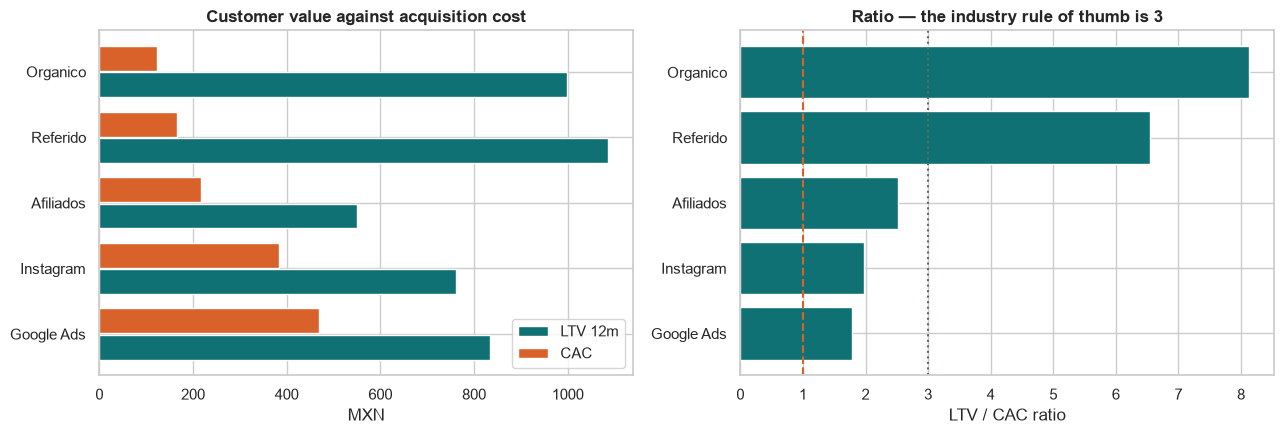

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ch = channel.sort_values("ratio_ltv_cac")
x = np.arange(len(ch))
axes[0].barh(x - 0.2, ch["ltv_promedio"], height=0.38, color=TEAL, label="LTV 12m")
axes[0].barh(x + 0.2, ch["cac_promedio"], height=0.38, color=CORAL, label="CAC")
axes[0].set_yticks(x)
axes[0].set_yticklabels(ch.index)
axes[0].set_xlabel("MXN")
axes[0].set_title("Customer value against acquisition cost")
axes[0].legend()

axes[1].barh(x, ch["ratio_ltv_cac"], color=TEAL)
axes[1].axvline(1, color=CORAL, linestyle="--", linewidth=1.5)
axes[1].axvline(3, color=GREY, linestyle=":", linewidth=1.5)
axes[1].set_yticks(x)
axes[1].set_yticklabels(ch.index)
axes[1].set_xlabel("LTV / CAC ratio")
axes[1].set_title("Ratio — the industry rule of thumb is 3")
plt.tight_layout()
plt.show()

### The finding

The dashed line at 1 is break-even; the line at 3 is the ratio the industry treats as healthy, because it leaves room for operating costs.

**Referido and Organico are excellent. Google Ads and Instagram barely clear break-even.**

### What you can act on

**Review Google Ads.** At a ratio of 1.78 the channel barely pays for its own acquisition, leaving nothing for inventory, logistics or operations. This decision needs no causal claim — you are already
spending the money and you know what you get back.

**Invest more in referrals.** Even if you doubled the incentive and CAC rose to $300, the ratio would still be 3.8.

### What you cannot conclude

Nobody assigned customers to channels at random. The ranking describes **who arrives**, not what the channel does to them — the point from topic 1.1: **association is not causation**.

So "Instagram destroys value" does not follow: the channel reaches a different segment, and may be the only one bringing new volume at scale. Answering that needs an experiment, not a bigger dataset.

---
# 7. Relationships between variables

## 7.1 Correlation, and what it hides

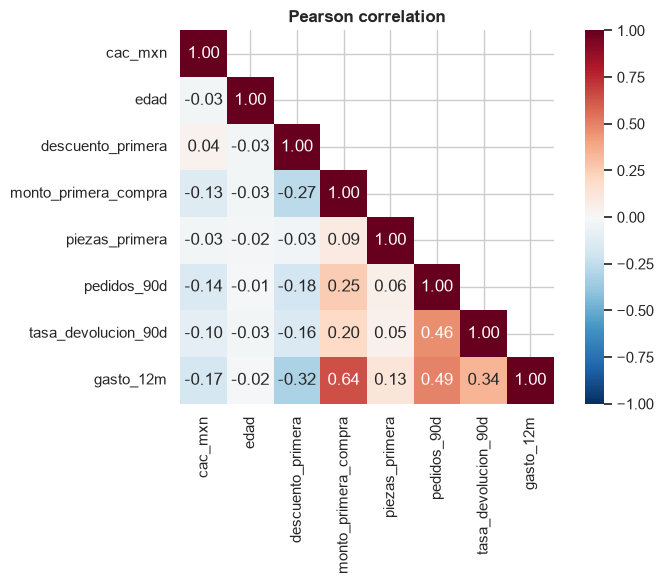

In [27]:
numeric = ["cac_mxn", "edad", "descuento_primera", "monto_primera_compra",
           "piezas_primera", "pedidos_90d", "tasa_devolucion_90d", "gasto_12m"]

corr = df[numeric].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson correlation")
plt.tight_layout()
plt.show()

## 7.2 Initial discount

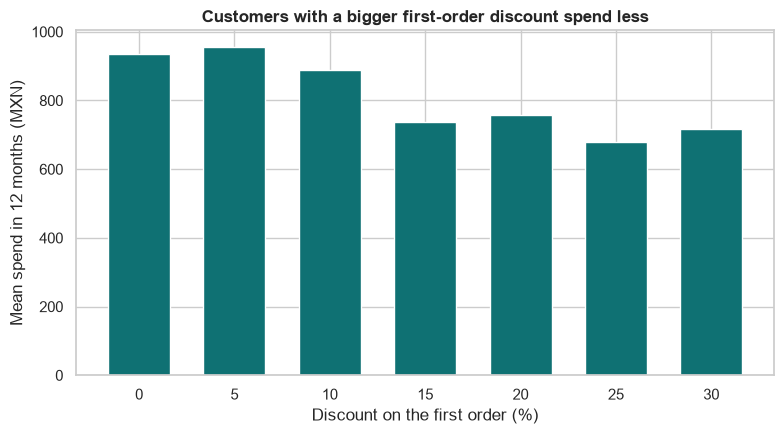

,n,gasto_medio
descuento_primera,,
0,676,935.0
5,189,956.0
10,94,890.0
15,253,738.0
20,291,757.0
25,263,680.0
30,170,718.0


In [28]:
disc = df.groupby("descuento_primera").agg(
    n=("id_cliente", "size"),
    gasto_medio=("gasto_12m", "mean"),
).round(0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(disc.index.astype(str), disc["gasto_medio"], color=TEAL, width=0.65)
ax.set_xlabel("Discount on the first order (%)")
ax.set_ylabel("Mean spend in 12 months (MXN)")
ax.set_title("Customers with a bigger first-order discount spend less")
plt.tight_layout()
plt.show()

disc

### The naive reading

*"Discounts destroy value. Customers who received 30% off spend roughly 40% less than those who paid
full price. Stop discounting."*

### Why that is wrong

The discount was **not assigned at random**. Marketing used aggressive discounts precisely to attract
price-sensitive customers who would not have bought otherwise. The discount is a **symptom of the
segment**, not a cause of the behaviour.

We can find evidence for this in the data: look at how the discount is distributed across channels.

In [29]:
tab = pd.crosstab(df["canal_adquisicion"], df["descuento_primera"] >= 15, normalize="index") * 100
tab.columns = ["Discount < 15%", "Discount >= 15%"]
tab.sort_values("Discount >= 15%", ascending=False).round(1)

,Discount < 15%,Discount >= 15%
canal_adquisicion,,
Afiliados,18.8,81.2
Instagram,46.3,53.7
Google Ads,53.1,46.9
Organico,65.5,34.5
Referido,68.2,31.8


There it is. Aggressive discounts are concentrated in **Afiliados**, the channel with the lowest
customer value. The discount is entangled with the channel, and the channel is entangled with the
kind of person who arrives through it.

### Does the effect survive within a channel?

In [30]:
within = df.groupby(["canal_adquisicion", df["descuento_primera"] >= 15])["gasto_12m"].mean().unstack()
within.columns = ["Discount < 15%", "Discount >= 15%"]
within["difference_%"] = ((within.iloc[:, 1] / within.iloc[:, 0] - 1) * 100).round(1)
within.round(0)

,Discount < 15%,Discount >= 15%,difference_%
canal_adquisicion,,,
Afiliados,634.0,530.0,-16.0
Google Ads,893.0,765.0,-14.0
Instagram,810.0,721.0,-11.0
Organico,1025.0,950.0,-7.0
Referido,1150.0,945.0,-18.0


The gap shrinks substantially once you compare like with like. Part of what looked like a discount effect was really a channel effect.

**What EDA can and cannot conclude:** it cannot tell you whether discounts destroy value. Only an experiment can — randomise who receives the discount and compare.

## 7.3 Return rate

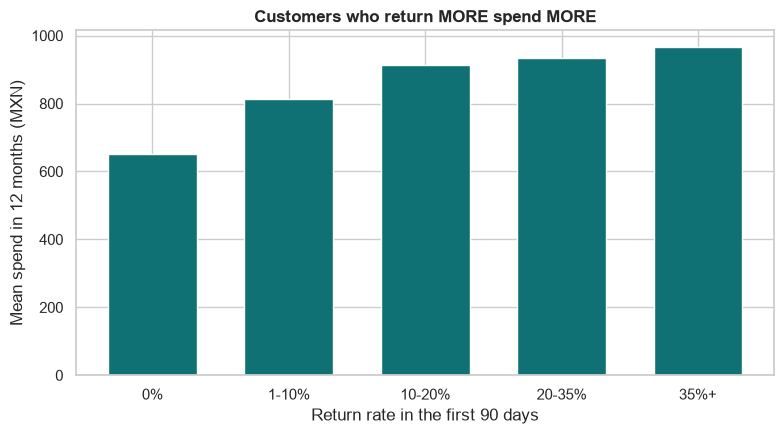

,n,gasto_medio,pedidos_90d
dev_bin,,,
0%,533,650.9,0.0
1-10%,438,812.6,1.8
10-20%,365,913.8,2.1
20-35%,371,933.2,2.2
35%+,229,966.7,2.2


In [31]:
tmp = df.copy()
tmp["dev_bin"] = pd.cut(tmp["tasa_devolucion_90d"],
                        bins=[-0.01, 0.001, 0.10, 0.20, 0.35, 1.0],
                        labels=["0%", "1-10%", "10-20%", "20-35%", "35%+"])

ret = tmp.groupby("dev_bin", observed=True).agg(
    n=("id_cliente", "size"),
    gasto_medio=("gasto_12m", "mean"),
    pedidos_90d=("pedidos_90d", "mean"),
).round(1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ret.index.astype(str), ret["gasto_medio"], color=TEAL, width=0.65)
ax.set_xlabel("Return rate in the first 90 days")
ax.set_ylabel("Mean spend in 12 months (MXN)")
ax.set_title("Customers who return MORE spend MORE")
plt.tight_layout()
plt.show()

ret

### The finding that sounds absurd

Customers who return the most merchandise are the **most valuable**. The 35%+ group spends more than
double the group that never returns anything.

### The explanation

Look at the `pedidos_90d` column. **You cannot return what you never bought.** A high return rate is
a symptom of high activity: customers who order a lot try more things, keep some and send others
back. A zero return rate mostly identifies customers who ordered once and disappeared.

Returns are not causing the spend. Activity is causing both.

## 7.4 The variables that do predict

Not everything is a trap. Some relationships are exactly what they look like.

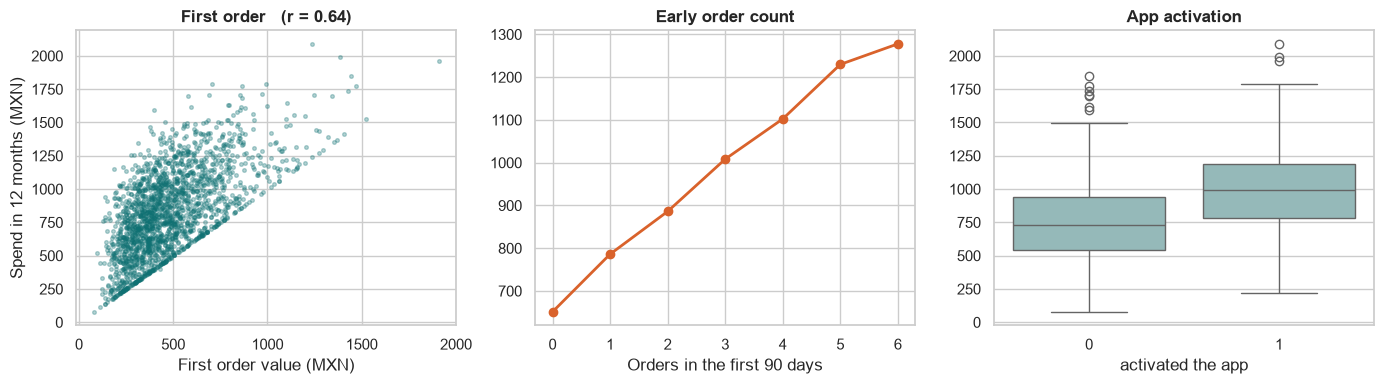

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(df["monto_primera_compra"], df["gasto_12m"], s=7, alpha=0.3, color=TEAL)
axes[0].set_xlabel("First order value (MXN)")
axes[0].set_ylabel("Spend in 12 months (MXN)")
r = df[["monto_primera_compra", "gasto_12m"]].corr().iloc[0, 1]
axes[0].set_title(f"First order   (r = {r:.2f})")

order_profile = df.groupby("pedidos_90d")["gasto_12m"].agg(["mean", "size"]).query("size >= 20")
axes[1].plot(order_profile.index, order_profile["mean"], marker="o", color=CORAL, linewidth=2)
axes[1].set_xlabel("Orders in the first 90 days")
axes[1].set_ylabel("")
axes[1].set_title("Early order count")

sns.boxplot(data=df, x="activo_app_90d", y="gasto_12m", ax=axes[2], color="#8FBFBF")
axes[2].set_xlabel("activated the app")
axes[2].set_ylabel("")
axes[2].set_title("App activation")

plt.tight_layout()
plt.show()

The first-order value is the strongest single day-0 predictor, and that is useful precisely because
it is known immediately.

The app panel deserves a warning. The gap is large — but this is **the same structure as the two
traps above**. Did the app make them spend more, or did the customers who were already engaged go and
download it? EDA cannot tell you. An A/B test can.

## 7.5 Categorical variables

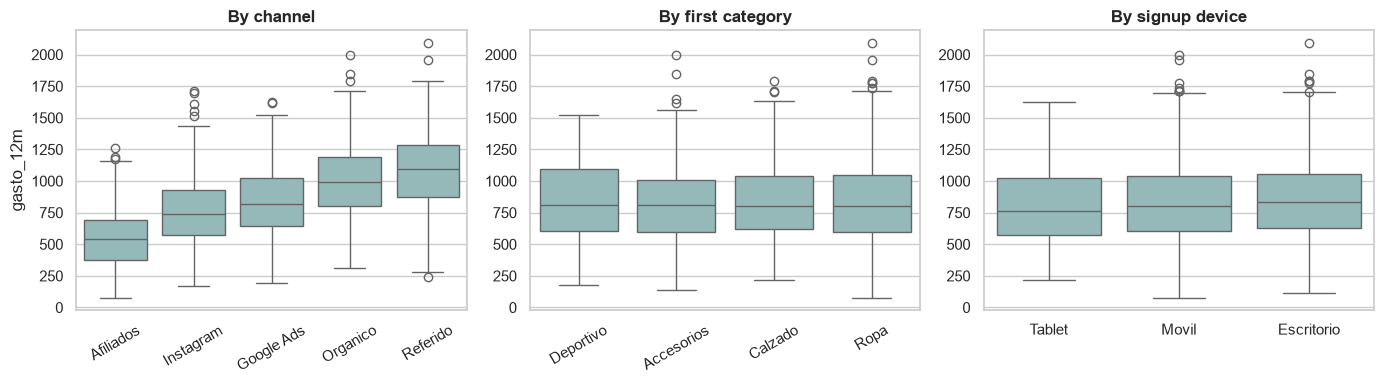

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

order = df.groupby("canal_adquisicion")["gasto_12m"].median().sort_values().index
sns.boxplot(data=df, x="canal_adquisicion", y="gasto_12m", order=order,
            ax=axes[0], color="#8FBFBF")
axes[0].set_title("By channel")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_xlabel("")

sns.boxplot(data=df, x="categoria_primera", y="gasto_12m", ax=axes[1], color="#8FBFBF")
axes[1].set_title("By first category")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.boxplot(data=df, x="dispositivo_registro", y="gasto_12m", ax=axes[2], color="#8FBFBF")
axes[2].set_title("By signup device")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

---
# 8. The variance structure

We know the response is positive and skewed. The remaining question: **does the spread stay constant
or does it grow with the mean?** The answer decides which member of the exponential family fits.

| If you observe | Then | Distribution |
|---|---|---|
| sd constant | Var = σ² | Normal |
| sd ∝ √mean | Var = μ | Poisson |
| sd ∝ mean | Var = φμ² | Gamma |

In [34]:
tmp = df.copy()
tmp["group"] = pd.qcut(tmp["monto_primera_compra"], 10, duplicates="drop")

var_profile = tmp.groupby("group", observed=True)["gasto_12m"].agg(["mean", "std", "size"])
var_profile["cv"] = (var_profile["std"] / var_profile["mean"]).round(3)
var_profile.round(1)

,mean,std,size,cv
group,,,,
"(77.999, 240.0]",505.4,246.4,196,0.5
"(240.0, 294.0]",615.0,227.0,194,0.4
"(294.0, 340.0]",682.0,248.7,194,0.4
"(340.0, 385.0]",734.5,236.7,192,0.3
"(385.0, 431.0]",804.5,247.2,198,0.3
"(431.0, 485.0]",828.7,251.0,194,0.3
"(485.0, 548.0]",891.5,238.9,189,0.3
"(548.0, 638.0]",972.7,256.3,192,0.3
"(638.0, 770.0]",1027.9,245.4,196,0.2


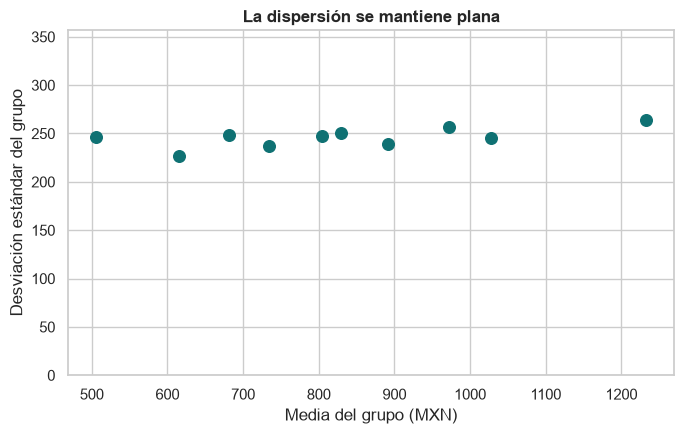

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(var_profile["mean"], var_profile["std"], s=70, color=TEAL)
ax.set_ylim(0, var_profile["std"].max() * 1.35)
ax.set_xlabel("Media del grupo (MXN)")
ax.set_ylabel("Desviación estándar del grupo")
ax.set_title("La dispersión se mantiene plana")
plt.tight_layout()
plt.show()

### The conclusion of the whole notebook

Look at the `std` column in the table above: it barely moves. Group means range from around \$480 to
\$1,300 — they almost triple — while the standard deviation stays close to \$250 throughout.

That is **constant variance**, or homoscedasticity: the spread of the response does not depend on its
level.

Put that together with what section 5 showed — approximately symmetric, no meaningful skew, points
following the line in the Q-Q plot — and the formulation for step 2 is the classical one:

$$Y_i \sim \mathcal{N}(\mu_i, \sigma^2), \qquad \mu_i = \mathbf{x}_i^T\boldsymbol\beta$$

A **normal linear model with an identity link**.

---
# 9. Which variables are you actually allowed to use?

Back to the temporal structure from the very beginning. It is not bureaucracy — it decides what is
usable for each business question.

In [36]:
dia0 = ["canal_adquisicion", "cac_mxn", "cohorte_mes", "ciudad", "dispositivo_registro",
        "edad", "newsletter", "descuento_primera", "monto_primera_compra",
        "categoria_primera", "piezas_primera"]

d90 = ["pedidos_90d", "dias_a_segunda_compra_90d", "tasa_devolucion_90d",
       "activo_app_90d", "recompro_90d"]

print(f"Known at day 0     : {len(dia0)} variables")
print(f"Known at 90 days   : {len(d90)} variables")
print(f"Response (12 months): gasto_12m")

Known at day 0     : 11 variables
Known at 90 days   : 5 variables
Response (12 months): gasto_12m


---
# 10. What the EDA delivered

Step 1 of the cycle is finished. This is what we hand to step 2.

### On data quality
- 15 duplicated rows removed
- Impossible values (negative first order, zero spend, age 0) converted to `NaN`
- `canal_adquisicion` and `ciudad` normalised: whitespace, capitalisation, text placeholder
- Missing response values dropped, **never imputed**
- `edad` identified as **MAR**, dependent on the acquisition channel, imputed by group
- `dias_a_segunda_compra_90d` identified as **structural missingness**: the `NaN` means "did not
  come back", and it became an indicator rather than an imputed number

### On the response
- Continuous, strictly positive, and **approximately symmetric** — mean and median nearly coincide
- The Q-Q plot follows the reference line through the bulk of the distribution
- **The variance is constant**: the standard deviation stays near \$250 regardless of the level
- Symmetry plus homoscedasticity means the **normal linear model** is the appropriate formulation,
  with an identity link and additively interpreted coefficients

### On the explanatory variables
- `monto_primera_compra` is the strongest day-0 predictor
- `pedidos_90d` and `recompro_90d` are the strongest 90-day predictors
- `descuento_primera` correlates negatively **because of who received discounts**, not because
  discounts destroy value
- `tasa_devolucion_90d` correlates positively **because returns are a symptom of activity**
- The channel ranking by LTV/CAC is clear, but describes who arrives, not what the channel does

### What we still do not know
Whether any of this is causal. Discounts, the app, and the channels were all self-selected or
assigned by marketing, never at random. Answering "does the app increase spend?" requires an
experiment, not a bigger dataset.


## Ejercicios

**Entrega:** un notebook con tu código y, para cada ejercicio, dos o tres renglones de conclusiónescrita. Se califica la interpretación.

1. **¿Hay relación entre `cohorte_mes` y el gasto?**
   Cuidado: el mes es **cíclico** — diciembre y enero son vecinos, no están a once unidades de
   distancia.

2. **`piezas_primera` y `categoria_primera` no aparecieron en el análisis.**
   Explóralas: ¿alguna se relaciona con el gasto a 12 meses? Si no, ¿vale la pena conservarlas?

3. **`dispositivo_registro` tampoco apareció.**
   ¿Se relaciona con el gasto? ¿Y con el canal de adquisición? Si ambas respuestas son sí, compara el gasto por dispositivo dentro de cada canal y di si el dispositivo aporta algo por su cuenta.

4. **¿El efecto de `activo_app_90d` sobre el gasto es igual en todos los canales?**
   Construye una tabla dinámica y di si ves una interacción.

## 1. ¿Hay relación entre `cohorte_mes` y el gasto?

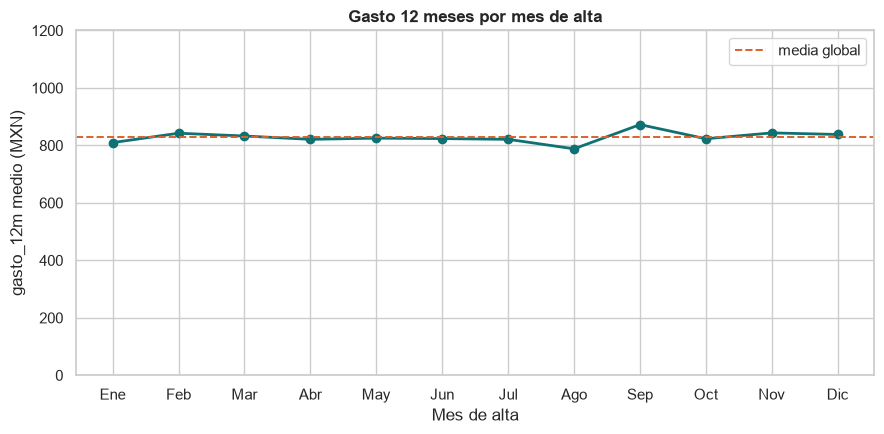

In [37]:
mes_nom = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
           7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

cohort = df.groupby("cohorte_mes")["gasto_12m"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cohort.index, cohort.values, marker="o", color=TEAL, linewidth=2)
ax.axhline(df["gasto_12m"].mean(), color=CORAL, linestyle="--", linewidth=1.4, label="media global")
ax.set_ylim(0, 1200)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([mes_nom[m] for m in range(1, 13)])
ax.set_ylabel("gasto_12m medio (MXN)")
ax.set_xlabel("Mes de alta")
ax.set_title("Gasto 12 meses por mes de alta")
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión.** Las personas que compran en verano tienen menos gasto posterior, puede significar que compran objetos de verano que no se usan en el año siguiente por lo tanto no vuelven a comprar

## 2. `piezas_primera` y `categoria_primera`


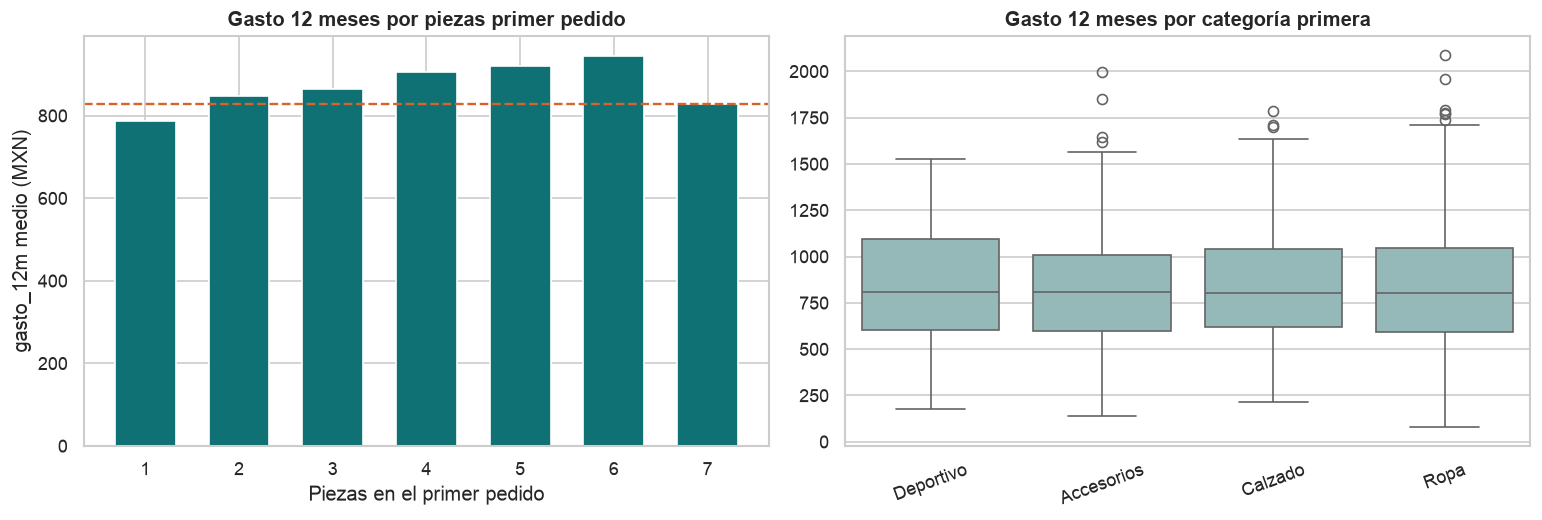

In [86]:
piezas = df.groupby("piezas_primera")["gasto_12m"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(piezas.index.astype(str), piezas.values, color=TEAL, width=0.65)
axes[0].axhline(df["gasto_12m"].mean(), color=CORAL, linestyle="--", linewidth=1.4)
axes[0].set_xlabel("Piezas en el primer pedido")
axes[0].set_ylabel("gasto_12m medio (MXN)")
axes[0].set_title("Gasto 12 meses por piezas primer pedido")

sns.boxplot(data=df, x="categoria_primera", y="gasto_12m", ax=axes[1], color="#8FBFBF")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("Gasto 12 meses por categoría primera")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Conclusión.** `piezas_primera` se relaciona débilmente con el gasto. a mayor piezas en el primer pedido, mayor gasto en los 12 meses posteriores. `categoria_primera` no se relaciona: las medias quedan entre $814 y $844. 


## 3. `dispositivo_registro`


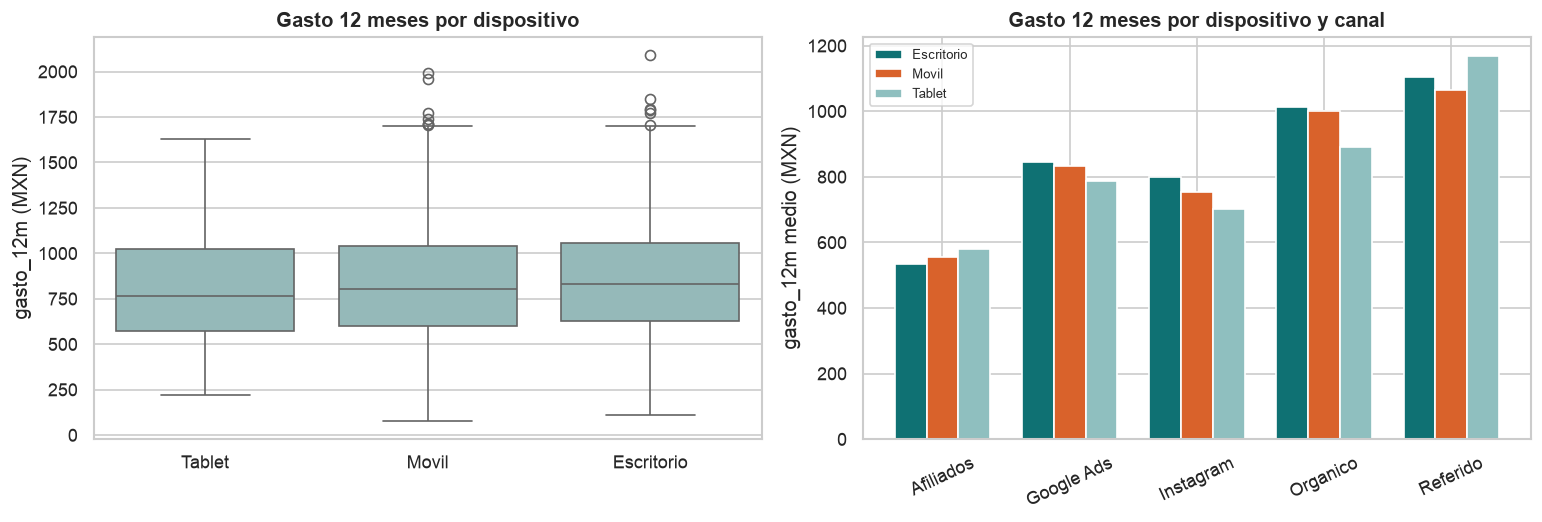

In [87]:
within = df.pivot_table(
    index="canal_adquisicion",
    columns="dispositivo_registro",
    values="gasto_12m",
    aggfunc="mean",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="dispositivo_registro", y="gasto_12m",
            order=["Tablet", "Movil", "Escritorio"], ax=axes[0], color="#8FBFBF")
axes[0].set_xlabel("")
axes[0].set_ylabel("gasto_12m (MXN)")
axes[0].set_title("Gasto 12 meses por dispositivo")

within.plot(kind="bar", ax=axes[1], color=["#0F7173", "#D9622B", "#8FBFBF"], width=0.75)
axes[1].set_xlabel("")
axes[1].set_ylabel("gasto_12m medio (MXN)")
axes[1].set_title("Gasto 12 meses por dispositivo y canal")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="", fontsize=8)
plt.tight_layout()
plt.show()

**Conclusión.** El dispositivo no se relaciona con el gasto. Seria interesante ver los modelos de dispositivo lo que si nos podria dar informacon.  Dentro de cada canal las diferencias por desipositivo son chicas contra a las del canal.


## 4. ¿El efecto de `activo_app_90d` es igual en todos los canales?


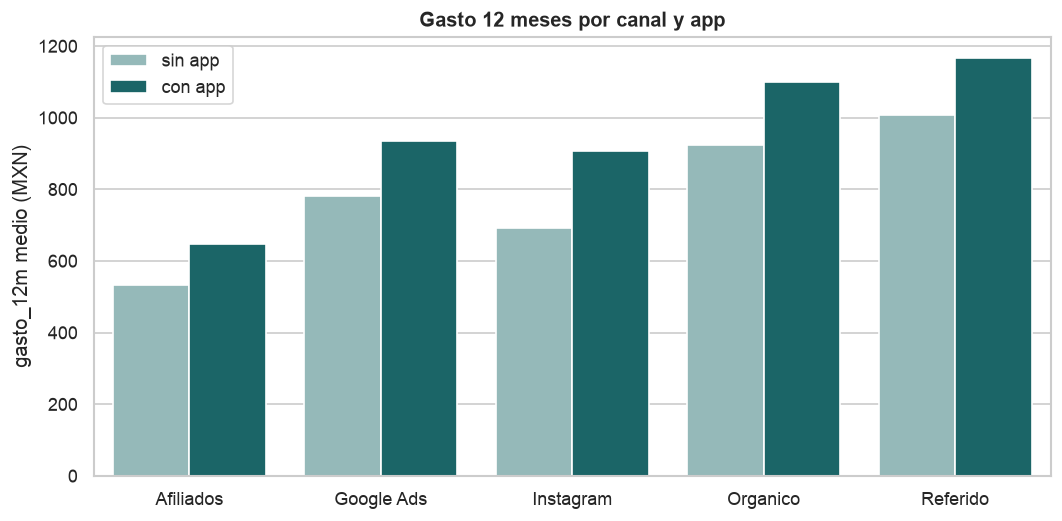

In [88]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = (
    df.groupby(["canal_adquisicion", "activo_app_90d"])["gasto_12m"]
      .mean()
      .reset_index()
)
sns.barplot(data=plot_df, x="canal_adquisicion", y="gasto_12m",
            hue="activo_app_90d", palette=["#8FBFBF", TEAL], ax=ax)
ax.set_xlabel("")
ax.set_ylabel("gasto_12m medio (MXN)")
ax.set_title("Gasto 12 meses por canal y app")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["sin app", "con app"], title="")
plt.tight_layout()
plt.show()

**Conclusión.** En todos los caneles, activar la app se asocia con más gasto en todos los canales.
